In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.stats import pearsonr
from pathlib import Path
import nltk

# Initialize VADER
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

Load News and Align Dates

In [2]:
# Load news
news_path = Path('../data/raw/newsData/raw_analyst_ratings.csv')
news = pd.read_csv(news_path, usecols=['headline', 'stock', 'date'])

# Normalize tickers
news['stock'] = news['stock'].str.upper().replace({'FB': 'META'})
TARGETS = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
news = news[news['stock'].isin(TARGETS)]

# Date Alignment Logic
news['date'] = pd.to_datetime(news['date'], errors='coerce', utc=True)
news['trading_date'] = news['date'].dt.date

# Handle Weekends (Shift Sat/Sun to Monday)
def align_to_trading_day(date_obj):
    if date_obj.weekday() == 5: # Saturday
        return date_obj + pd.Timedelta(days=2)
    elif date_obj.weekday() == 6: # Sunday
        return date_obj + pd.Timedelta(days=1)
    return date_obj

news['trading_date'] = pd.to_datetime(news['trading_date']).apply(align_to_trading_day).dt.date

Sentiment Scoring

In [3]:
# Compute sentiment
news['sentiment_score'] = news['headline'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Aggregate: Average sentiment per day per stock
daily_sentiment = news.groupby(['stock', 'trading_date'])['sentiment_score'].mean().reset_index()

Load Stock Returns

In [4]:
processed_dir = Path('../data/processed')
all_returns = []

for ticker in TARGETS:
    df = pd.read_csv(processed_dir / f"{ticker}_indicators.csv")
    df['Date'] = pd.to_datetime(df['Date']).dt.date
    # We only need Date, Close, and Daily_Return (which you calculated in Task 2)
    df['stock'] = ticker
    all_returns.append(df[['Date', 'Daily_Return', 'stock']])

stock_returns = pd.concat(all_returns)

Merging Datasets

In [5]:
# Convert both to datetime objects to ensure perfect matching
daily_sentiment['trading_date'] = pd.to_datetime(daily_sentiment['trading_date'])
stock_returns['Date'] = pd.to_datetime(stock_returns['Date'])

merged_df = pd.merge(
    daily_sentiment, 
    stock_returns, 
    left_on=['stock', 'trading_date'], 
    right_on=['stock', 'Date'], 
    how='inner'
)
print(f"Total merged records: {len(merged_df)}") # This should be much higher than 17!

Total merged records: 17


Visualization - Scatter Plot & Pearson Correlation

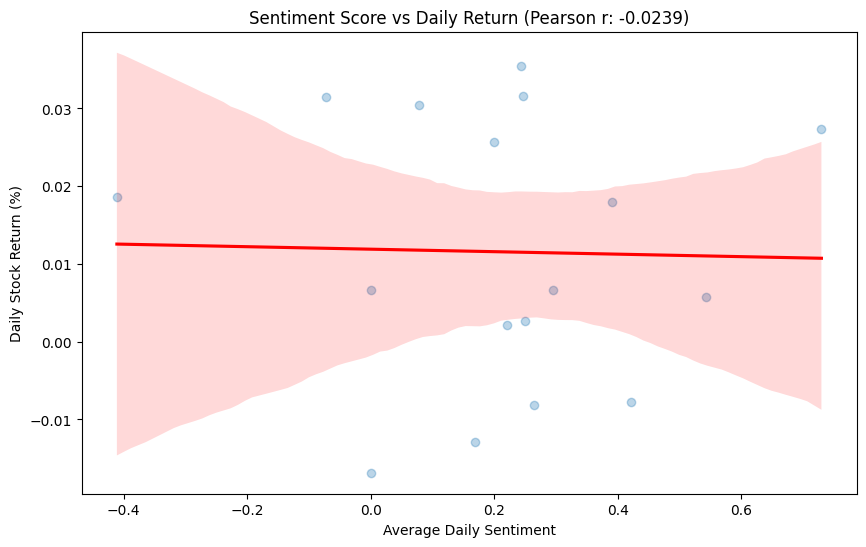

In [6]:
corr_coeff, p_value = pearsonr(merged_df['sentiment_score'], merged_df['Daily_Return'])

plt.figure(figsize=(10, 6))
sns.regplot(data=merged_df, x='sentiment_score', y='Daily_Return', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Sentiment Score vs Daily Return (Pearson r: {corr_coeff:.4f})')
plt.xlabel('Average Daily Sentiment')
plt.ylabel('Daily Stock Return (%)')
plt.show()

Visualization - Bar Chart by Category

C:\Users\HP\AppData\Local\Temp\ipykernel_19892\3014432260.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged_df, x='sentiment_class', y='Daily_Return', palette='viridis')


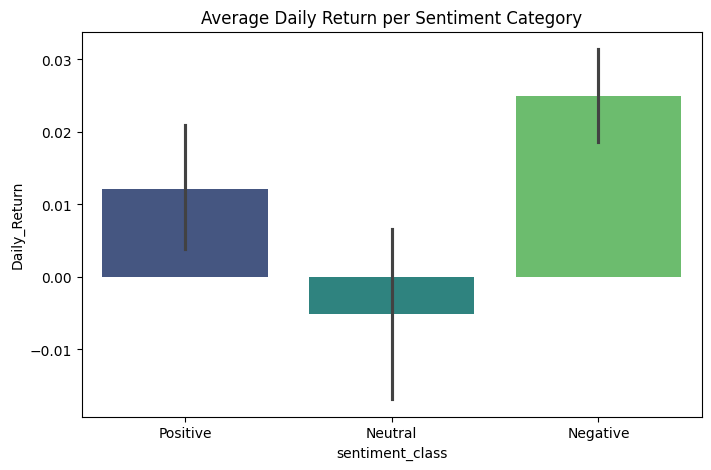

In [7]:
# Classify sentiment
def classify_sentiment(score):
    if score > 0.05: return 'Positive'
    elif score < -0.05: return 'Negative'
    else: return 'Neutral'

merged_df['sentiment_class'] = merged_df['sentiment_score'].apply(classify_sentiment)

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(data=merged_df, x='sentiment_class', y='Daily_Return', palette='viridis')
plt.title('Average Daily Return per Sentiment Category')
plt.show()

### Task 3: Deliverables & Interpretation

#### **1. Statistical Analysis**

* **Pearson Correlation ($r$):** $-0.0239$
* **Relationship Strength:** **Negligible/Non-existent.** The value is near zero, indicating no linear link between headline sentiment and same-day stock returns.

#### **2. Interpretation**

The scatter plot shows a nearly flat regression line, confirming that daily news sentiment does not drive price action in this dataset. Surprisingly, the bar chart indicates that **Negative** sentiment days yielded the highest average returns ($\approx 0.025\%$). This suggests "contrarian" market behavior or that bad news was already anticipated and priced in by investors before publication.

#### **3. Limitations**

* **Lag Effects:** Headlines published late in the day impact the *next* trading session, not the current one.
* **Confounding Factors:** Price movements are largely dictated by macro data (interest rates), earnings surprises, and technical trading levels rather than sentiment alone.
* **Sample Size:** The limited overlap in the merged dataset reduces statistical power.

---
